In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

In [27]:
df_train = pd.read_csv('../data/processed/2017/2017_train_scaled.csv')
df_test = pd.read_csv('../data/processed/2017/2017_test_scaled.csv')

In [28]:
X_train_benign = df_train[df_train["Label"] == 0].drop(columns=["Label"])
X_test = df_test.drop(columns=["Label"])
y_train = df_train['Label']
y_test = df_test['Label']

In [31]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32,latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [33]:
input_dim = X_train_benign.shape[1]
model = Autoencoder(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tensor = torch.tensor(X_train_benign.values, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True)

losses = []

for epoch in range(30):
    model.train()
    total_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    epoch_loss = total_loss / len(loader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.6f}")

Epoch 1 | Loss: 0.206649
Epoch 2 | Loss: 0.137189
Epoch 3 | Loss: 0.112263
Epoch 4 | Loss: 0.101944
Epoch 5 | Loss: 0.091342
Epoch 6 | Loss: 0.086004
Epoch 7 | Loss: 0.082243
Epoch 8 | Loss: 0.080645
Epoch 9 | Loss: 0.077675
Epoch 10 | Loss: 0.075897
Epoch 11 | Loss: 0.074329
Epoch 12 | Loss: 0.071716
Epoch 13 | Loss: 0.072316
Epoch 14 | Loss: 0.070011
Epoch 15 | Loss: 0.069541
Epoch 16 | Loss: 0.067190
Epoch 17 | Loss: 0.068652
Epoch 18 | Loss: 0.065817
Epoch 19 | Loss: 0.065795
Epoch 20 | Loss: 0.063964
Epoch 21 | Loss: 0.063693
Epoch 22 | Loss: 0.063693
Epoch 23 | Loss: 0.065201
Epoch 24 | Loss: 0.063294
Epoch 25 | Loss: 0.062724
Epoch 26 | Loss: 0.061511
Epoch 27 | Loss: 0.061863
Epoch 28 | Loss: 0.060053
Epoch 29 | Loss: 0.056782
Epoch 30 | Loss: 0.054505


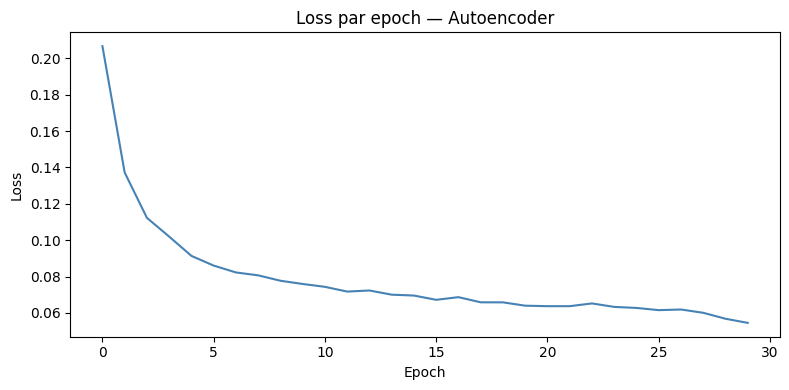

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color="steelblue")
plt.title("Loss par epoch — Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [47]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    reconstructed = model(X_test_tensor)
    errors = ((X_test_tensor - reconstructed) ** 2).mean(dim=1).numpy()

benign_errors = errors[y_test.values == 0]

threshold = np.percentile(benign_errors, 95)

print(f"Seuil : {threshold:.6f}")
y_pred = (errors > threshold).astype(int)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC : {roc_auc_score(y_test, errors):.4f}")

Seuil : 0.882195
              precision    recall  f1-score   support

           0       0.85      0.95      0.90    454265
           1       0.61      0.32      0.42    111311

    accuracy                           0.83    565576
   macro avg       0.73      0.64      0.66    565576
weighted avg       0.80      0.83      0.80    565576

ROC-AUC : 0.6427


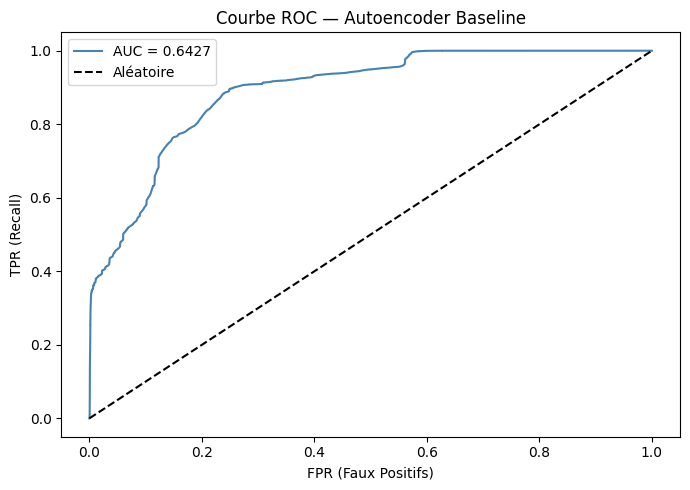

In [45]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, errors):.4f}", color="steelblue")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("FPR (Faux Positifs)")
plt.ylabel("TPR (Recall)")
plt.title("Courbe ROC — Autoencoder Baseline")
plt.legend()
plt.tight_layout()
plt.show()